# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [1]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [1]:
!cat configs/linear_regression_untrained.yaml

# Config file for ResNet18 untrained, to be used as backbone for linear regression.

experiment_name: "linear_regression_untrained"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: False
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "regression"  # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 30
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "MSELoss" unused since we set it in train.py based on task
save_best: True
weight_decay: 0.0001

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.0001
Setup complete! Ready to begin training epochs.


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.34it/s, loss=353]


Epoch [1/30] Train Loss: 406.2210, Train MAE: 15.4398, Train MSE: 406.2210, Train Acc@3: 0.1424, Train Acc@5: 0.2374 | Val Loss: 353.2782, Val MAE: 14.4358, Val MSE: 353.2782, Val Acc@3: 0.1672, Val Acc@5: 0.2523, Val MAE: 14.4358


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.38it/s, loss=352]


Epoch [2/30] Train Loss: 346.1444, Train MAE: 14.2544, Train MSE: 346.1444, Train Acc@3: 0.1594, Train Acc@5: 0.2573 | Val Loss: 352.1135, Val MAE: 14.1975, Val MSE: 352.1135, Val Acc@3: 0.1427, Val Acc@5: 0.2320, Val MAE: 14.1975


...

Epoch [28/30] Train Loss: 33.1866, Train MAE: 4.3612, Train MSE: 33.1866, Train Acc@3: 0.4499, Train Acc@5: 0.6650 | Val Loss: 128.2902, Val MAE: 8.1081, Val MSE: 128.2902, Val Acc@3: 0.2917, Val Acc@5: 0.4402, Val MAE: 8.1081


100%|###########################################################################################################################################| 76/76 [00:37<00:00,  2.04it/s, loss=124]


Epoch [29/30] Train Loss: 32.9180, Train MAE: 4.3066, Train MSE: 32.9180, Train Acc@3: 0.4595, Train Acc@5: 0.6689 | Val Loss: 124.4756, Val MAE: 8.0063, Val MSE: 124.4756, Val Acc@3: 0.2942, Val Acc@5: 0.4465, Val MAE: 8.0063


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.37it/s, loss=131]


Epoch [30/30] Train Loss: 28.4734, Train MAE: 4.0344, Train MSE: 28.4734, Train Acc@3: 0.4829, Train Acc@5: 0.6921 | Val Loss: 130.9451, Val MAE: 8.2165, Val MSE: 130.9451, Val Acc@3: 0.2797, Val Acc@5: 0.4444, Val MAE: 8.2165
Saving Best Val MAE: 7.6190 at Epoch 30
Saved model with MAE = 7.6190
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_regression_untrained.npy
Training completely finished! Best Val Loss: 121.4345, Best Val MAE: 7.6190


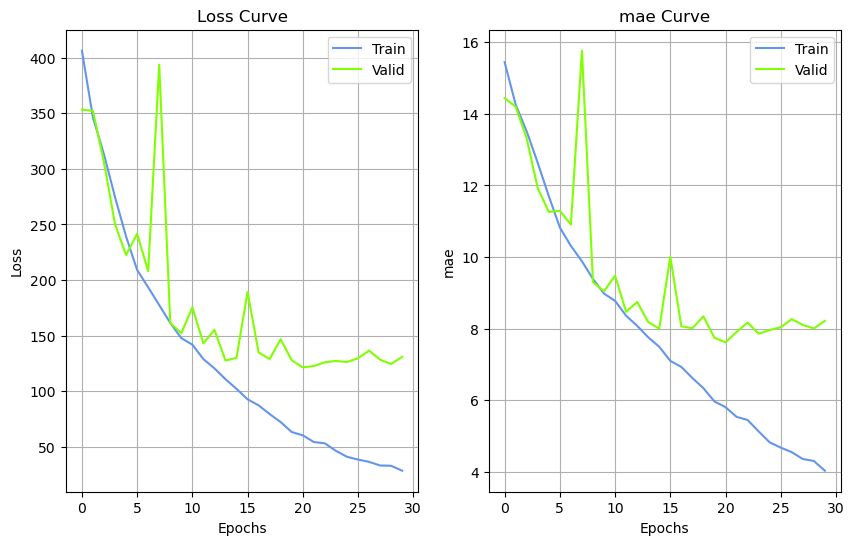

In [2]:
%run scripts/train.py --config configs/linear_regression_untrained.yaml

# Evaluate randomly initialized ResNet18

In [3]:
%run scripts/evaluate.py --config configs/linear_regression_untrained.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_regression_untrained.pth


100%|###########################################################################################################################################| 76/76 [00:30<00:00,  2.48it/s, loss=116]


Evaluation Metrics — linear_regression_untrained
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   7.4851 |
| MSE    | 116.1874 |
| Acc@3  |   0.3372 |
| Acc@5  |   0.4965 |
+--------+----------+


# Plot Validation MAE by Epochs


Epochs 0-10: Best Val MAE = 9.0458
Epochs 0-20: Best Val MAE = 7.7467
Epochs 0-30: Best Val MAE = 7.6190


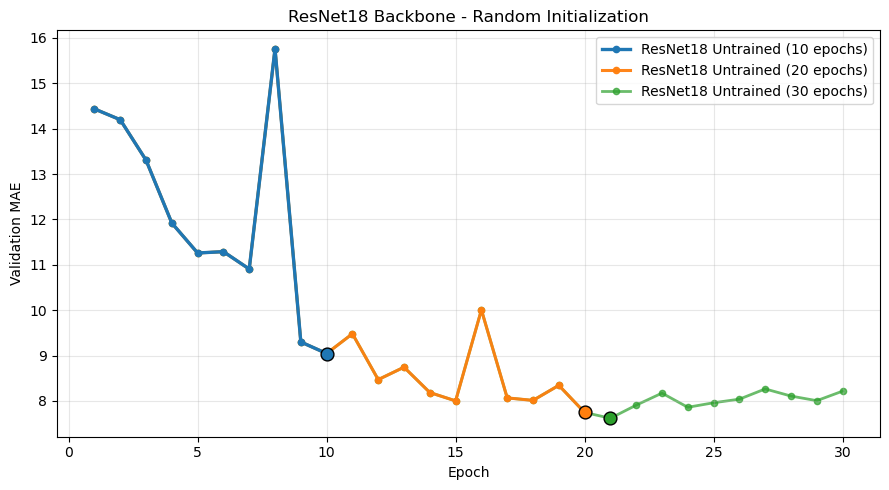

In [5]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_regression_untrained.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Random Initialization', label='ResNet18 Untrained')